# Day 15 — Convolutional Neural Networks (CNN)

**Hands-on Colab Notebook — MNIST Digit Classification**


## 1. Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print('TensorFlow:', tf.__version__)


TensorFlow: 2.20.0


## 2. Load MNIST Dataset

MNIST contains 28×28 grayscale handwritten digit images for classes 0–9.


In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print('Training images:', X_train.shape)
print('Training labels:', y_train.shape)
print('Testing images :', X_test.shape)
print('Testing labels :', y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


## 3. Visualize Sample Images


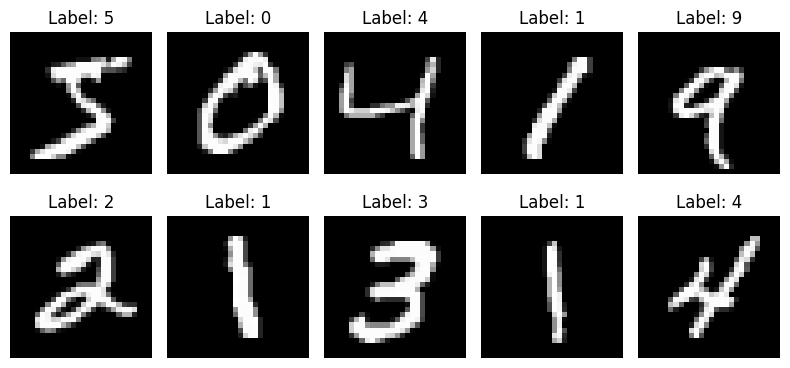

In [3]:
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Normalize Pixel Values

Convert pixel values from 0–255 to 0–1.


In [4]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(X_train.min(), X_train.max())


0.0 1.0


## 5. Add Channel Dimension

MNIST is grayscale, so it has one image channel.


In [5]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print('Training shape:', X_train.shape)
print('Testing shape :', X_test.shape)


Training shape: (60000, 28, 28, 1)
Testing shape : (10000, 28, 28, 1)


# PART A — BUILD A CNN

Architecture: Input → Conv2D → ReLU → MaxPooling → Conv2D → ReLU → MaxPooling → Flatten → Dense → Output


In [6]:
model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the CNN

Optimizer: Adam | Loss: Sparse Categorical Cross-Entropy | Metric: Accuracy


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 7. Train the CNN


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.9430 - loss: 0.1917 - val_accuracy: 0.9783 - val_loss: 0.0751
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9821 - loss: 0.0581 - val_accuracy: 0.9818 - val_loss: 0.0625
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9875 - loss: 0.0410 - val_accuracy: 0.9882 - val_loss: 0.0397
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9909 - loss: 0.0299 - val_accuracy: 0.9888 - val_loss: 0.0441
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9921 - loss: 0.0250 - val_accuracy: 0.9882 - val_loss: 0.0433


## 8. Training vs Validation Accuracy


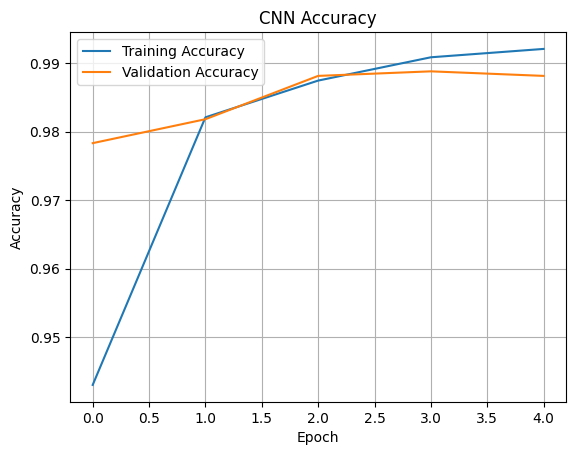

In [9]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.grid()
plt.show()


## 9. Training vs Validation Loss


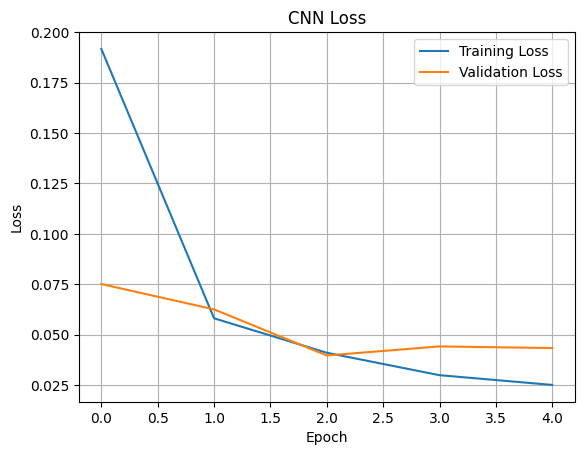

In [10]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.grid()
plt.show()


## 10. Evaluate the CNN


In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)


Test Loss: 0.030810358002781868
Test Accuracy: 0.9902999997138977


## 11. Make Predictions


In [12]:
probabilities = model.predict(X_test[:10], verbose=0)
predictions = np.argmax(probabilities, axis=1)

print('Predicted:', predictions)
print('Actual   :', y_test[:10])


Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual   : [7 2 1 0 4 1 4 9 5 9]


## 12. Visualize Predictions


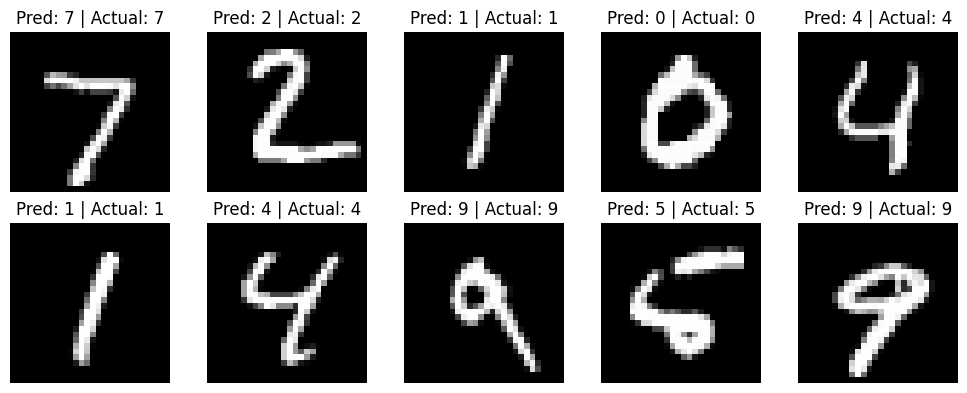

In [13]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f'Pred: {predictions[i]} | Actual: {y_test[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


## 13. Confusion Matrix


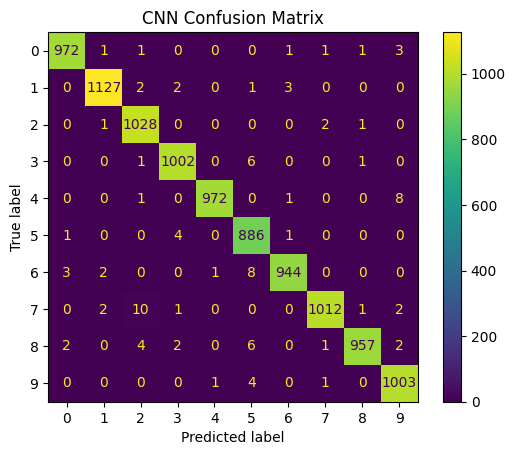

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_probabilities = model.predict(X_test, verbose=0)
all_predictions = np.argmax(all_probabilities, axis=1)

cm = confusion_matrix(y_test, all_predictions)
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot()
plt.title('CNN Confusion Matrix')
plt.show()


## 14. Classification Report


In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, all_predictions))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.97      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 15. Predict a Single Image


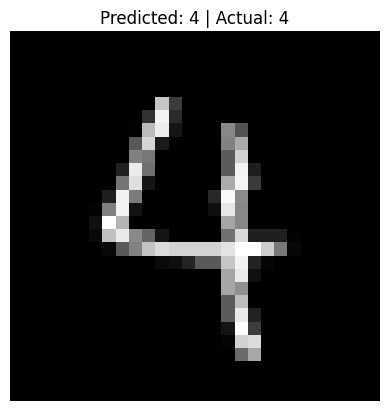

In [16]:
index = 24
single_image = X_test[index:index+1]
probability = model.predict(single_image, verbose=0)
prediction = np.argmax(probability, axis=1)[0]

plt.imshow(X_test[index].squeeze(), cmap='gray')
plt.title(f'Predicted: {prediction} | Actual: {y_test[index]}')
plt.axis('off')
plt.show()


# 🎯 Final Flow

`Image → Conv2D → ReLU → MaxPooling → Conv2D → ReLU → MaxPooling → Flatten → Dense → Softmax → Prediction`
